#Simulación Monte Carlo de las Propieades Magnéticas y Efecto Magnetocalórico en un Antiferromagneto Tipo-A: Estudio del Modelo de Ising 2D
*Fundamentos en Magnetismo*

Sofía Moscoso Ortíz

Mario César Barrera Salas

---



En este trabajo se estudian las propiedades magn´eticas y el efecto magnetocal´orico (EMC) en un
modelo de Ising 2D sobre una red cuadrada que representa la f´ısica esencial de un antiferromagneto
tipo-A. Mediante simulaciones de Monte Carlo empleando el algoritmo de Metr´opolis, se analizan
el par´ametro de orden (magnetizaci´on de subred Ms), la susceptibilidad χs, el calor espec´ıfico Cv y
el cumulante de Binder U bajo condiciones de frontera peri´odicas y libres para tama˜nos de red de
L = 16 y L = 24. Se determina la temperatura de N´eel (TN ) y se eval´ua la variaci´on de entrop´ıa
magn´etica (∆SM ) y el poder de enfriamiento relativo (RCP) mediante la relaci´on de Maxwel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numba import njit, prange
# ==================

#Parte A: Implementacion y Calibracion
Funciones Base. Implementacion del modelo, condiciones de frontera y algoritmo de metropolis.

Se considera una red cuadrada 2D de tamaño $L \times L$ ($N = L^2$) con espines $S_i = \pm 1$. El Hamiltoniano del sistema está dado por:
\begin{equation}
H = -J_1 \sum_{\langle i,j \rangle} S_i S_j - J_2 \sum_{\langle\langle i,j \rangle\rangle} S_i S_j - h \sum_i S_i,    (1)
\end{equation}
donde $\langle i,j \rangle$ representa la suma sobre primeros vecinos, $\langle\langle i,j \rangle\rangle$ sobre segundos vecinos, y $h$ es el campo magnético externo. En las simulaciones se fija la razón de competencia $J_2 / J_1 = -0.6$.

Las simulaciones se ejecutan mediante el algoritmo de Metrópolis. Un paso Monte Carlo (MCS) equivale a $N$ intentos de volteo de espín. Para asegurar el equilibrio térmico, se descartan $N_{\text{term}}$ pasos iniciales de termalización, seguidos de $N_{\text{muestra}}$ pasos de muestreo para promediar las variables termodinámicas (1) y (2):

$$M_s = \frac{1}{2N} \left| \sum_{i \in A} S_i - \sum_{j \in B} S_j \right|         (2)$$

In [ ]:
@njit(cache=True, fastmath=True)
def energia_local(grid, i, j, N, J1, J2, periodic):
    ip1 = i + 1
    im1 = i - 1
    jp1 = j + 1
    jm1 = j - 1

    if periodic: #condiciones de frontera periodicas
        if ip1 == N: ip1 = 0
        if im1 == -1: im1 = N - 1
        if jp1 == N: jp1 = 0
        if jm1 == -1: jm1 = N - 1

        sumFM  = grid[im1, j] + grid[ip1, j] + grid[i, jm1] + grid[i, jp1]
        sumAFM = grid[im1, jm1] + grid[ip1, jm1] + grid[im1, jp1] + grid[ip1, jp1]

    else:  # condiciones de fronteras libres
        has_up    = i > 0
        has_down  = i < N - 1
        has_left  = j > 0
        has_right = j < N - 1

        sumFM = 0.0
        if has_up:    sumFM += grid[im1, j]
        if has_down:  sumFM += grid[ip1, j]
        if has_left:  sumFM += grid[i, jm1]
        if has_right: sumFM += grid[i, jp1]

        sumAFM = 0.0
        if has_up and has_left:    sumAFM += grid[im1, jm1]
        if has_up and has_right:   sumAFM += grid[im1, jp1]
        if has_down and has_left:  sumAFM += grid[ip1, jm1]
        if has_down and has_right: sumAFM += grid[ip1, jp1]

    return -grid[i, j] * (J1 * sumFM + J2 * sumAFM)


@njit(cache=True, fastmath=True)
def Energy_total(grid, periodic):
    N = grid.shape[0]
    J1, J2 = 1.0, -0.6
    E = 0.0
    for a in range(N):
        for b in range(N):
            E += energia_local(grid, a, b, N, J1, J2, periodic)
    return E / 2.0


@njit(cache=True, fastmath=True)
def magnetizacion(grid):

  L = grid.shape[0]

  i, j = np.indices(grid.shape)

  patron = (-1)**j
  patronh = (-1)**i

  Ms_v = abs(np.sum(grid * patron)) / (L*L)
  Ms_h = abs(np.sum(grid * patronh)) / (L*L)

  return max(Ms_v, Ms_h)


@njit(cache=True, fastmath=True)
def MCS(L, N, J1, J2, T, kB, periodic):    #Implementacion del modelo
  grid = np.empty((L, L), dtype=np.int8)
  for i in range(L):
      for j in range(L):
          grid[i, j] = 1 if np.random.random() < 0.5 else -1

  E = np.empty(N)
  M = np.empty(N)

  for y in range(N):
    for k in range(L * L):
      a = np.random.randint(0, L)
      b = np.random.randint(0, L)

      E_initial = energia_local(grid, a, b, L, J1, J2, periodic)  #Algoritmo de metropolis
      delta_E = -2.0 * E_initial

      if delta_E < 0 or np.random.random() < np.exp(-delta_E / (kB * T)):
        grid[a, b] *= -1

    E[y] = Energy_total(grid, periodic)
    M[y] = magnetizacion(grid)

  return E, M

##Pruebas
Visualizacion de un comportamiento adecuado de la simulacion y de la forma en la que la red se magnetiza. Ejecucion de Prueba

In [ ]:
E_ , M_, grid = MCS(L=16 , N=10000 , J1=1 , J2=-0.6 , T=0.6 , kB=1 , periodic =True)

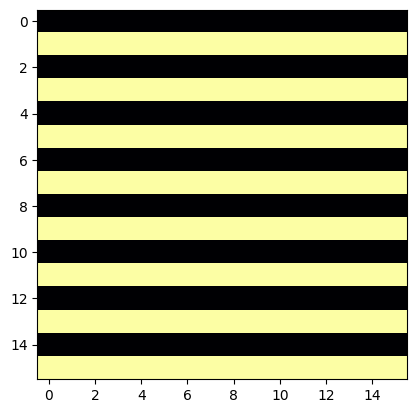

In [ ]:
plt.imshow(grid, cmap='inferno', vmin=-1, vmax=1, interpolation='nearest')

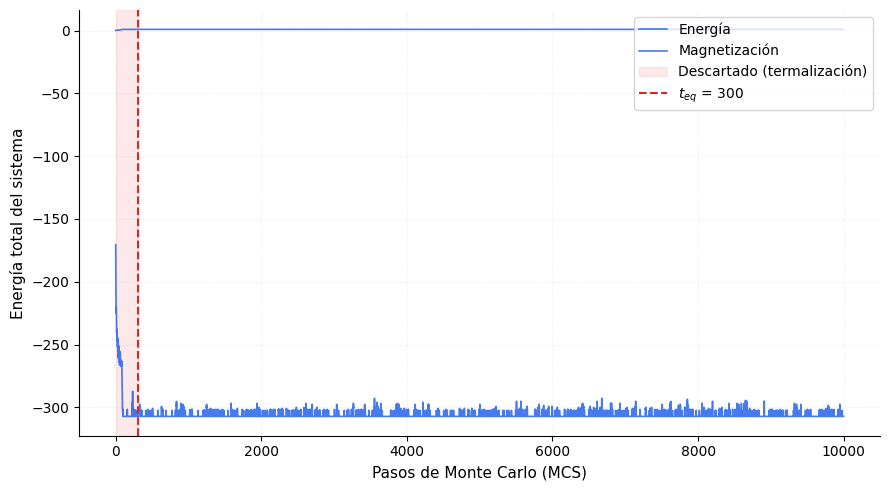

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(E_, color='#2563eb', linewidth=1.2, alpha=0.85, label='Energía')
ax.plot(M_, color='#2563eb', linewidth=1.2, alpha=0.85, label='Magnetización')
ax.axvspan(0, 300, color='#f87171', alpha=0.15, label=f'Descartado (termalización)')
ax.axvline(x=300, color='#dc2626', linestyle='--', linewidth=1.5, label=f'$t_{{eq}}$ = {300}')    # Línea vertical en t_eq

ax.set_xlabel("Pasos de Monte Carlo (MCS)", fontsize=11)
ax.set_ylabel("Energía total del sistema", fontsize=11)
#ax.set_title(f"{titulo}  (T = {T})", fontsize=13, fontweight='bold')
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.grid(alpha=0.25, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.set_xlim(3, 7)
#ax.set_ylim(20, 60)

plt.tight_layout()
plt.show()

Nota: En temperaturas mayores a uno la grafica diverge(no se da termalizacion). Probar con más (+100000) pasos N de montecarlo

##Condiciones de Frontera Libres vs Condiciones de Frontera Periodicas
Comparacion de la simulacion de montecarlo entre las condiciones de frontera libres y las condiciones de frontera periodicas.

In [ ]:
E_libre, M_libre = MCS(L=16, N=100000, J1=1, J2=-0.6, T=0.5 , kB=1, periodic=False)
E_p, M_p = MCS(L=16, N=100000, J1=1, J2=-0.6, T=0.5 , kB=1, periodic=True)

/tmp/ipykernel_6806/242864361.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


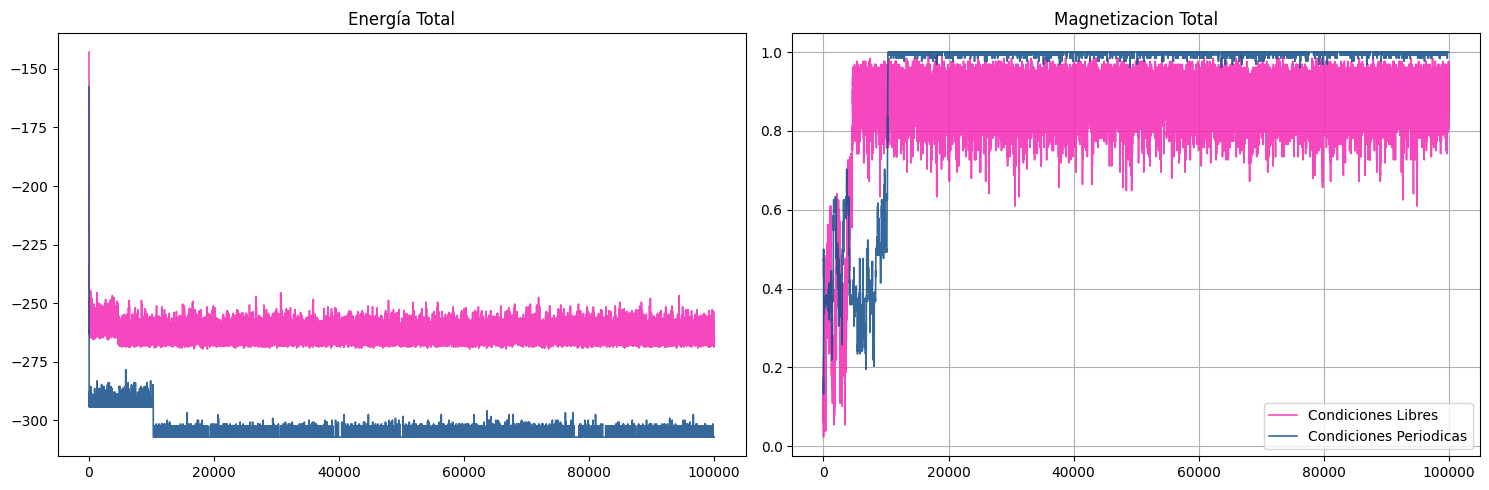

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(E_libre, color='#F527B4', linewidth=1.2, alpha=0.85, label='Condiciones Libres')
axs[0].plot(E_p, color='#134E8A', linewidth=1.2, alpha=0.85, label='Condiciones Periodicas')
axs[0].set_title('Energía Total')
#axs[0].axvline(x=t_li[30], color='red', linestyle='--', linewidth=1.5, label=f'$tlibres_{{eq}}$ = {t_li[900]}')
#axs[0].axvline(x=t_p[30], color='blue', linestyle='--', linewidth=1.5, label=f'$tperiodicas_{{eq}}$ = {t_p[0]}')

axs[1].plot(M_libre, color='#F527B4', linewidth=1.2, alpha=0.85, label='Condiciones Libres')
axs[1].plot(M_p, color='#134E8A', linewidth=1.2, alpha=0.85, label='Condiciones Periodicas')
axs[1].set_title('Magnetizacion Total')
#axs[1].axvline(x=0, color='#dc2626', linestyle='--', linewidth=1.5, label=f'$t_{{eq}}$ = {0}')


Nota: En el sistema con condiciones de frontera libres la energía es mayor. Ademas, el calculo de los observables es más inestable. La curva de magnetizacion tarda mucho tiempo en estabilizarse o simplemente no se estabiliza.

##Simulacion
Para cada tamaño de red y para cada condicion de frontera, simular el
sistema en un rango de temperaturas (ej. 0,1 ≤ T ≤ 3,0 en unidades de J1/kB, con
J2/J1 = −0,6, que es el caso base del artıculo). Calcular el promedio de Ms, E, χs, Cv,
U.

In [ ]:
@njit(cache=True, fastmath=True, parallel=True)
def barrido_temperaturas(L, N, T_array, J1, J2, kB, periodic):
    n_T = len(T_array)
    E_temperatures = np.empty((n_T, N))
    M_temperatures = np.empty((n_T, N))

    for t in prange(n_T):
        E, M = MCS(L, N, J1, J2, T_array[t], kB, periodic)
        E_temperatures[t, :] = E
        M_temperatures[t, :] = M

    return E_temperatures, M_temperatures

In [2]:
T = np.linspace(1.5,0.6, 40)

In [ ]:
E16_temperatures, M16_temperatures = barrido_temperaturas(
    L=16, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=True
)

E24_temperatures, M24_temperatures = barrido_temperaturas(
    L=24, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=True
)

In [ ]:
E16_temperatures_free, M16_temperatures_free = barrido_temperaturas(
    L=16, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=False
)

E24_temperatures_free, M24_temperatures_free = barrido_temperaturas(
    L=24, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=False
)

In [ ]:
T

array([1.5       , 1.47692308, 1.45384615, 1.43076923, 1.40769231,
       1.38461538, 1.36153846, 1.33846154, 1.31538462, 1.29230769,
       1.26923077, 1.24615385, 1.22307692, 1.2       , 1.17692308,
       1.15384615, 1.13076923, 1.10769231, 1.08461538, 1.06153846,
       1.03846154, 1.01538462, 0.99230769, 0.96923077, 0.94615385,
       0.92307692, 0.9       , 0.87692308, 0.85384615, 0.83076923,
       0.80769231, 0.78461538, 0.76153846, 0.73846154, 0.71538462,
       0.69230769, 0.66923077, 0.64615385, 0.62307692, 0.6       ])

###Visualizar Datos

In [ ]:
def visualizacion(lista, titulo='MCS'):

    titulos = ['0.85', '0.83', ' 0.8', '0.78','0.76', ' 0.73', '0.71', '0.69', "0.66" , "0.64" , "0.62" , "0.6" ]

    fig, axs = plt.subplots(3, 4, figsize=(18, 8))

    fig.suptitle(titulo, fontsize=18, fontweight='bold')

    for ax, E, nombre in zip(axs.flat, lista, titulos):

        ax.plot(E, linewidth=1.2)

        ax.set_title(nombre)
        ax.set_xlabel('Pasos MC')
        ax.set_ylabel('Observable')

        # Mismo eje X para las 8
        #x.set_xlim(0, 50000)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    plt.show()

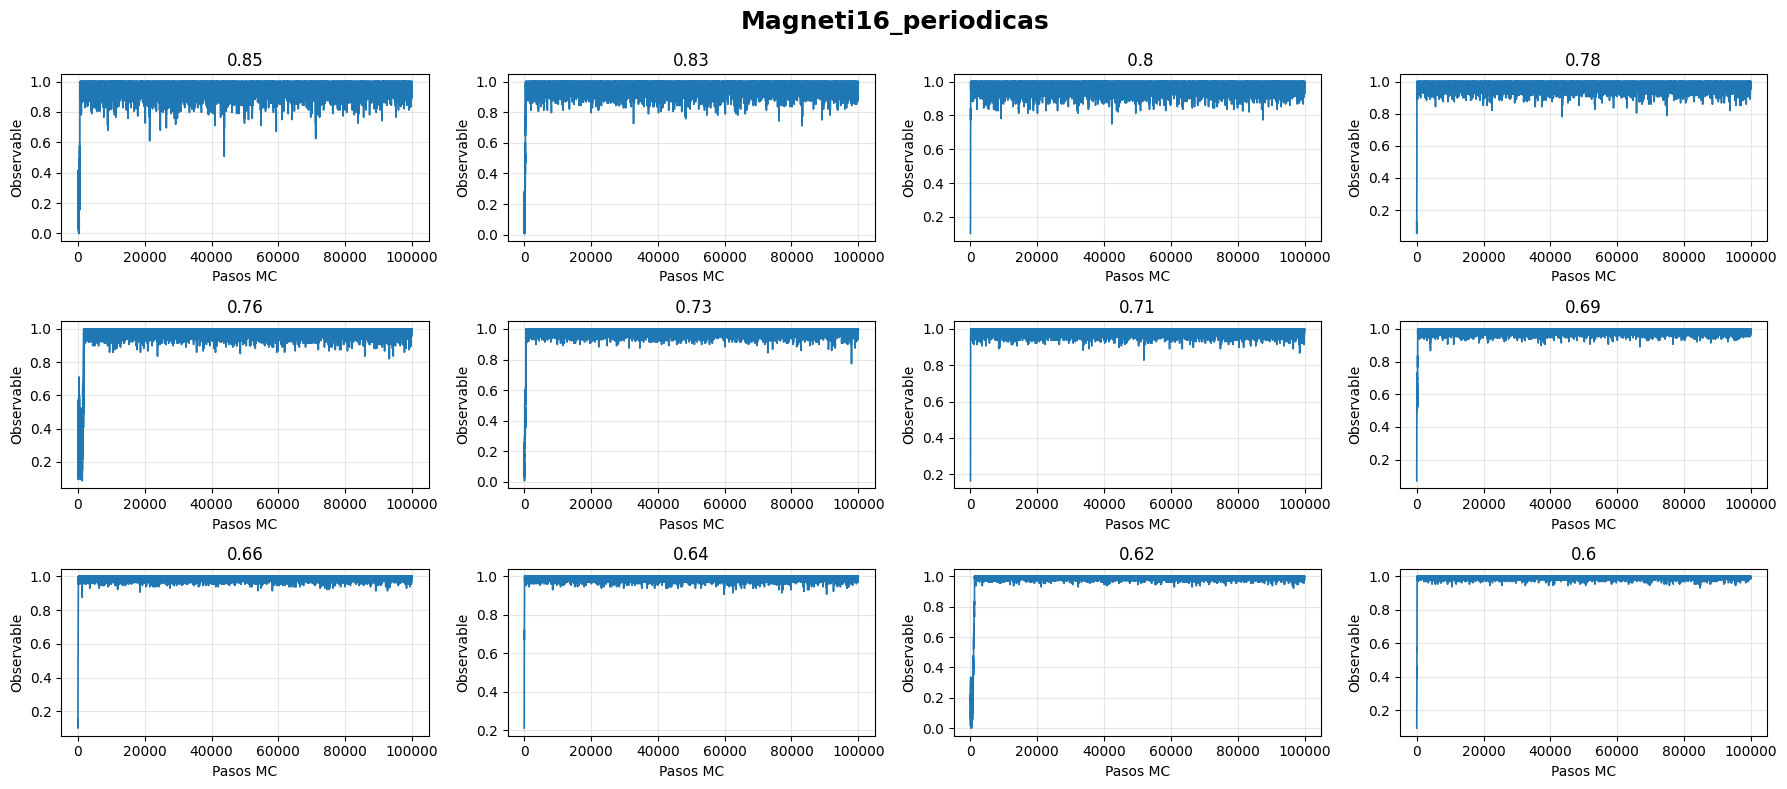

In [ ]:
visualizacion(M16_temperatures[28:], "Magneti16_periodicas")

###Energia vs Temperatura
Visualizacion del comportamiento de los datos en funcion de la temperatura.

In [ ]:
def Energy(energias):
  E_prom= []
  for E in energias:
    E_prom.append(np.array(E[20000:]).mean())
  return E_prom

In [ ]:
Eprom_16 = Energy(E16_temperatures)
Eprom_24 = Energy(E24_temperatures)

Mprom_16 = Energy(M16_temperatures)
Mprom_24 = Energy(M24_temperatures)

In [ ]:
Eprom_16_f = Energy(E16_temperatures_free)
Eprom_24_f = Energy(E24_temperatures_free)

Mprom_16_f = Energy(M16_temperatures_free)
Mprom_24_f = Energy(M24_temperatures_free)

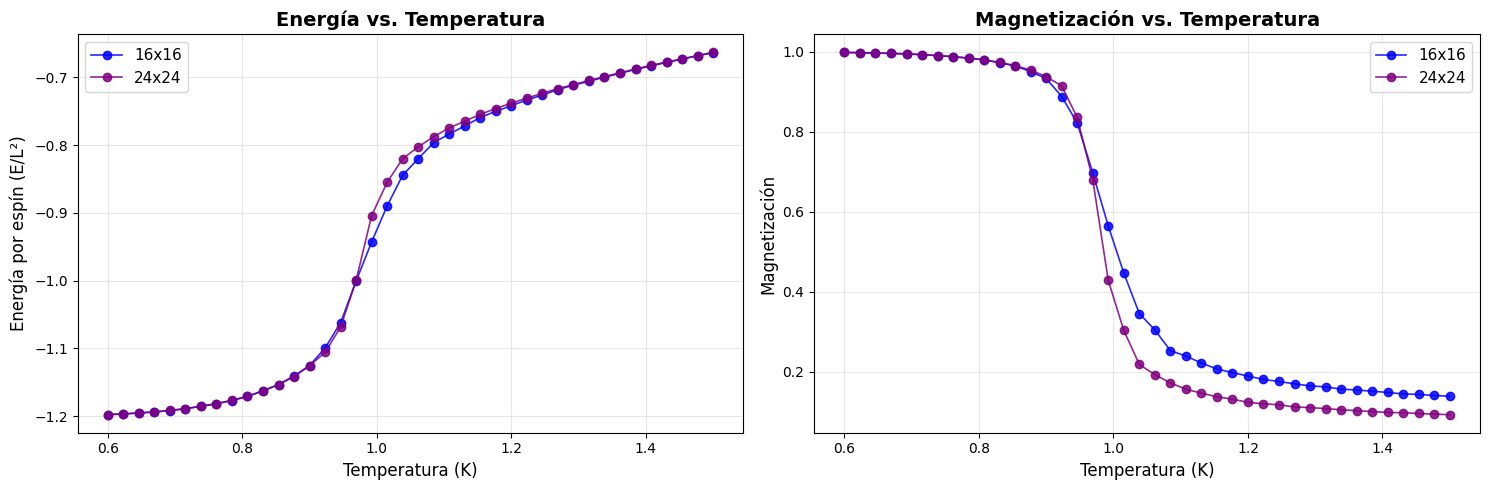

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# NORMALIZACIÓN: se divide la energía por L*L (número de espines) para poder
# comparar en igualdad de condiciones los tamaños 16x16 y 24x24 (la energía
# total escala con N = L*L, así que sin normalizar la comparación no es justa).
axs[0].plot(T, np.array(Eprom_16)/(16*16), "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, np.array(Eprom_24)/(24*24),  "-o",color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Energía vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía por espín (E/L²)', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, Mprom_16, "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, Mprom_24, "-o", color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].set_title('MagnetizacionVSTemperatura')
axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

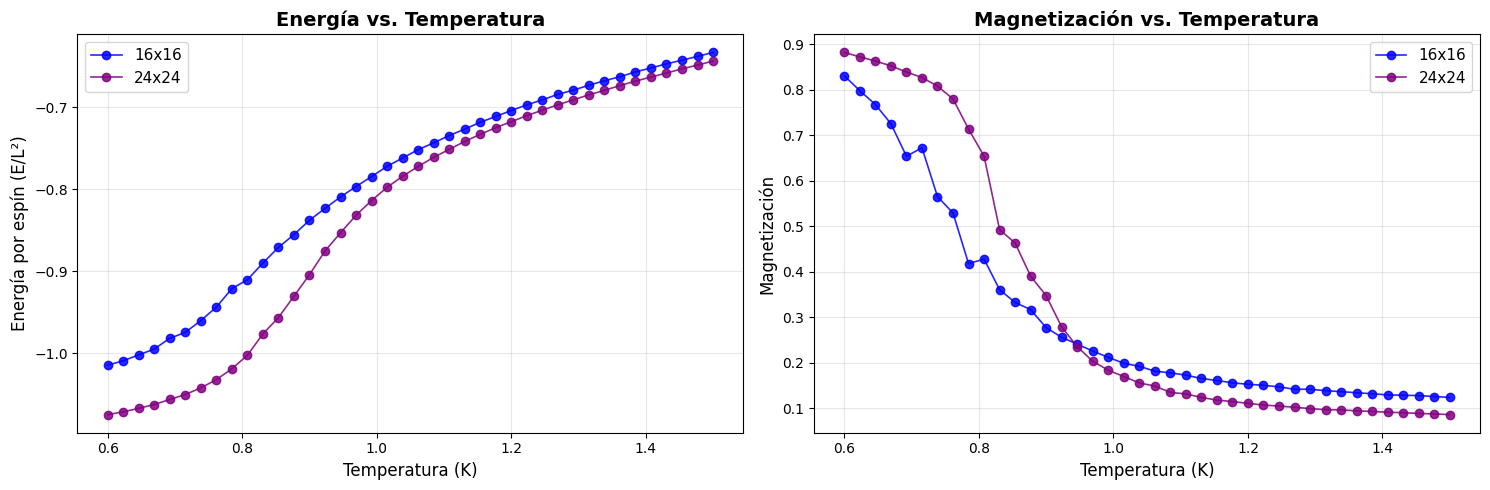

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(T, np.array(Eprom_16_f)/(16*16), "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, np.array(Eprom_24_f)/(24*24),  "-o",color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Energía vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía por espín (E/L²)', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, Mprom_16_f, "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, Mprom_24_f, "-o", color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].set_title('MagnetizacionVSTemperatura')
axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

##Gran promedio
Energía y magnetización configuracionales

In [ ]:
# Con fronteras libres el sistema tarda más en estabilizarse (ver nota más
# arriba: "la curva de magnetizacion tarda mucho tiempo en estabilizarse").
# Por eso se AUMENTAN los pasos de Monte Carlo respecto al caso periódico.
N_LIBRE        = 500000
t_rx_periodico = 20000    # pasos de termalización descartados (fronteras periódicas)
t_rx_libre     = 100000   # pasos de termalización descartados (fronteras libres, 20% de N_LIBRE)

In [ ]:
@njit(cache=True, fastmath=True, parallel=False)
def GranMean(L, N, Temp, periodic, n_configs=10, t_rx=20000):
    J1, J2 = 1.0, -0.6
    kB = 1.0

    E_config = np.empty(n_configs)
    M_config = np.empty(n_configs)

    for c in prange(n_configs):
        E_, M_ = MCS(L, N, J1, J2, Temp, kB, periodic)
        E_config[c] = E_[t_rx:].mean()
        M_config[c] = M_[t_rx:].mean()

    return E_config, M_config

In [ ]:
@njit(cache=True, fastmath=True, parallel=True)
def barrido_GranMean(L, N, T_array, periodic, n_configs=5, t_rx=20000):
    n_T = len(T_array)
    E_config_all = np.empty((n_T, n_configs))
    M_config_all = np.empty((n_T, n_configs))

    for t in prange(n_T):
        E_c, M_c = GranMean(L, N, T_array[t], periodic, n_configs, t_rx)  # GranMean debe ser secuencial (sin parallel=True)
        E_config_all[t, :] = E_c
        M_config_all[t, :] = M_c

    return E_config_all, M_config_all

In [ ]:
E16_config, M16_config = barrido_GranMean(L=16, N=100000, T_array=T, periodic=True)
E24_config, M24_config = barrido_GranMean(L=24, N=100000, T_array=T, periodic=True) #12minutos

In [ ]:
E16_config_free, M16_config_free = barrido_GranMean(L=16, N=N_LIBRE, T_array=T, periodic=False, t_rx=t_rx_libre)
E24_config_free, M24_config_free = barrido_GranMean(L=24, N=N_LIBRE, T_array=T, periodic=False, t_rx=t_rx_libre)

In [ ]:
E16_config = np.array(E16_config)
M16_config = np.array(M16_config)

E24_config = np.array(E24_config)
M24_config = np.array(M24_config)

In [ ]:
E16_config_free = np.array(E16_config_free)
M16_config_free = np.array(M16_config_free)

E24_config_free = np.array(E24_config_free)
M24_config_free = np.array(M24_config_free)

In [ ]:
#periodicas
E16_std  = E16_config.std(axis=1, ddof=1)      # ddof=1: desviación estándar muestral (no poblacional)
E16_sem  = E16_std / np.sqrt(E16_config.shape[1])  # dividir por sqrt(n_configs)
M16_std  = M16_config.std(axis=1, ddof=1)
M16_sem  = M16_std / np.sqrt(M16_config.shape[1])

E24_std  = E24_config.std(axis=1, ddof=1)
E24_sem  = E24_std / np.sqrt(E24_config.shape[1])
M24_std  = M24_config.std(axis=1, ddof=1)
M24_sem  = M24_std / np.sqrt(M24_config.shape[1])


In [ ]:

#libres
E16_std_free  = E16_config_free.std(axis=1, ddof=1)
E16_sem_free  = E16_std_free / np.sqrt(E16_config_free.shape[1])
M16_std_free  = M16_config_free.std(axis=1, ddof=1)
M16_sem_free  = M16_std_free / np.sqrt(M16_config_free.shape[1])

E24_std_free  = E24_config_free.std(axis=1, ddof=1)
E24_sem_free  = E24_std_free / np.sqrt(E24_config_free.shape[1])
M24_std_free  = M24_config_free.std(axis=1, ddof=1)
M24_sem_free  = M24_std_free / np.sqrt(M24_config_free.shape[1])

In [ ]:
# NORMALIZACIÓN: energía por espín (E/L²) para comparar 16x16 y 24x24.
N16, N24 = 16*16, 24*24

SuperPosicion de las 4 subredes

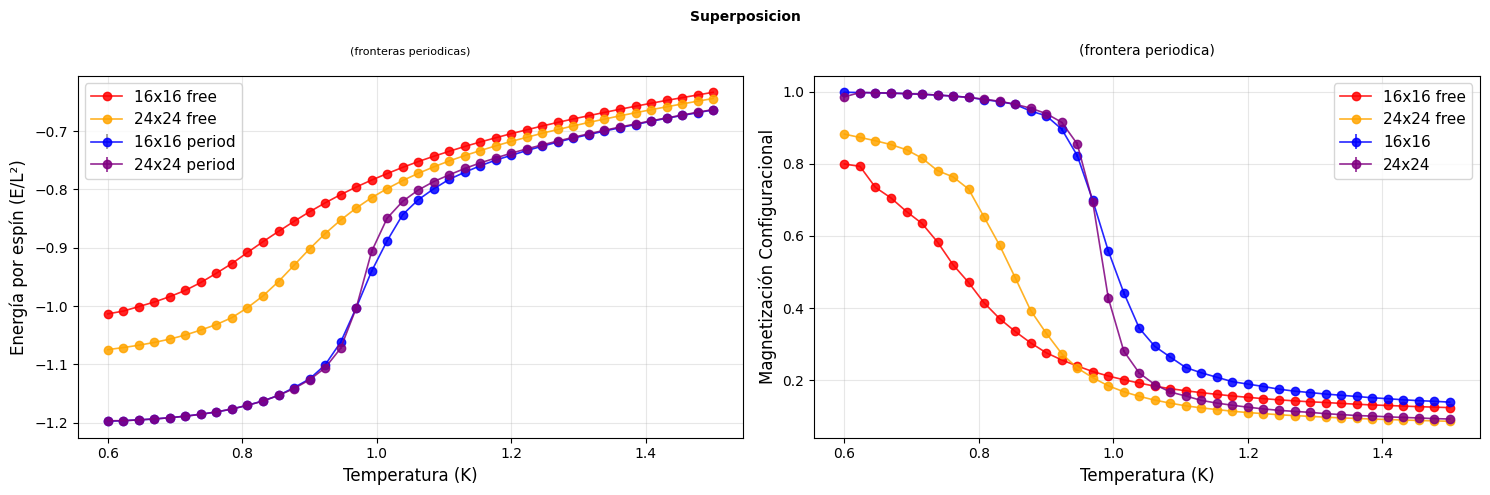

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Superposicion', fontsize=10, fontweight='bold')

axs[0].errorbar(T, E16_config.mean(axis=1)/N16, yerr=E16_sem/N16, fmt ="o-" , color='blue', ecolor='gray', linewidth=1.2, alpha=0.85, label='16x16 period')
axs[0].errorbar(T, E24_config.mean(axis=1)/N24, yerr=E24_sem/N24, fmt ="o-", color='purple', linewidth=1.2, alpha=0.85, label='24x24 period')
axs[0].plot(T, E16_config_free.mean(axis=1)/N16,  "-o", color='red', linewidth=1.2, alpha=0.85, label='16x16 free')
axs[0].plot(T, E24_config_free.mean(axis=1)/N24, "-o", color='orange', linewidth=1.2, alpha=0.85, label='24x24 free')
axs[0].set_title('Energía vs. Temperatura ', fontsize=14, fontweight='bold')
axs[0].set_title("(fronteras periodicas)", fontsize=8, loc="center", pad=15)
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía por espín (E/L²)', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].errorbar(T, M16_config.mean(axis=1), yerr=M16_sem, fmt ="o-" , color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, M24_config.mean(axis=1), yerr=M24_sem, fmt ="o-" ,  color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].plot(T, M16_config_free.mean(axis=1), "-o", color='red', linewidth=1.2, alpha=0.85, label='16x16 free')
axs[1].plot(T, M24_config_free.mean(axis=1),  "-o", color='orange', linewidth=1.2, alpha=0.85, label='24x24 free')
axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_title("(frontera periodica)", fontsize=10, loc="center", pad=15)
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización Configuracional', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

Redes Libres

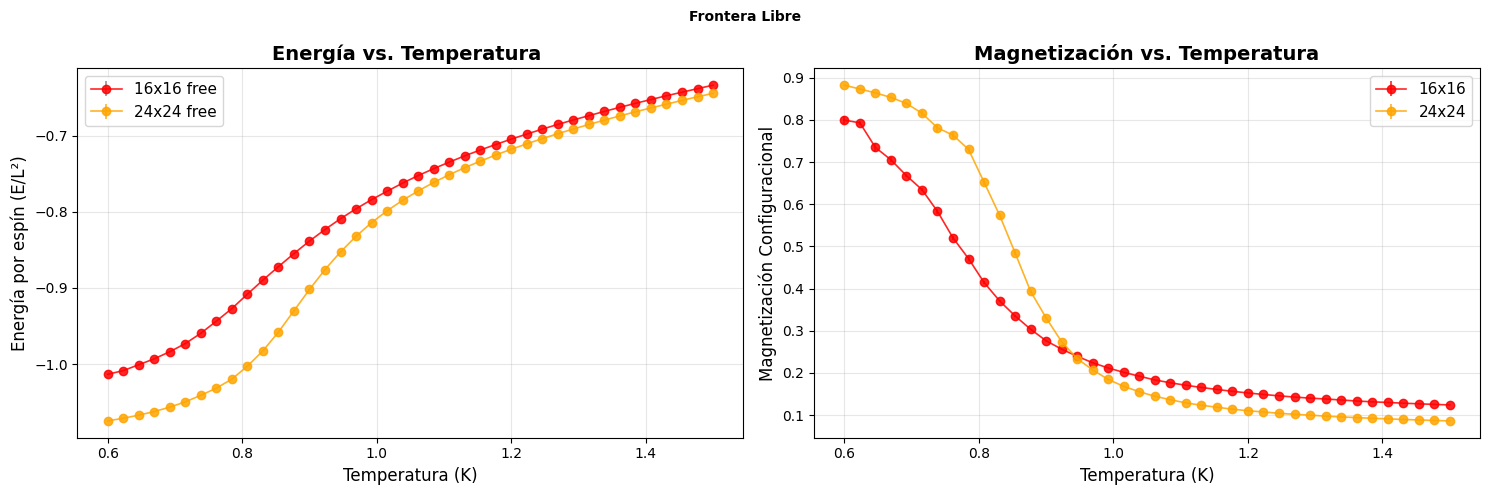

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Frontera Libre', fontsize=10, fontweight='bold')

axs[0].errorbar(T, E16_config_free.mean(axis=1)/N16, yerr=E16_sem_free/N16, fmt ="o-" , color='red', ecolor='gray', linewidth=1.2, alpha=0.85, label='16x16 free')
axs[0].errorbar(T, E24_config_free.mean(axis=1)/N24, yerr=E24_sem_free/N24, fmt ="o-", color='orange', linewidth=1.2, alpha=0.85, label='24x24 free')
axs[0].set_title('Energía vs. Temperatura ', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía por espín (E/L²)', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].errorbar(T, M16_config_free.mean(axis=1), yerr=M16_sem_free, fmt ="o-" , color='red', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, M24_config_free.mean(axis=1), yerr=M24_sem_free, fmt ="o-" ,  color='orange', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización Configuracional', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

Redes Periodicas

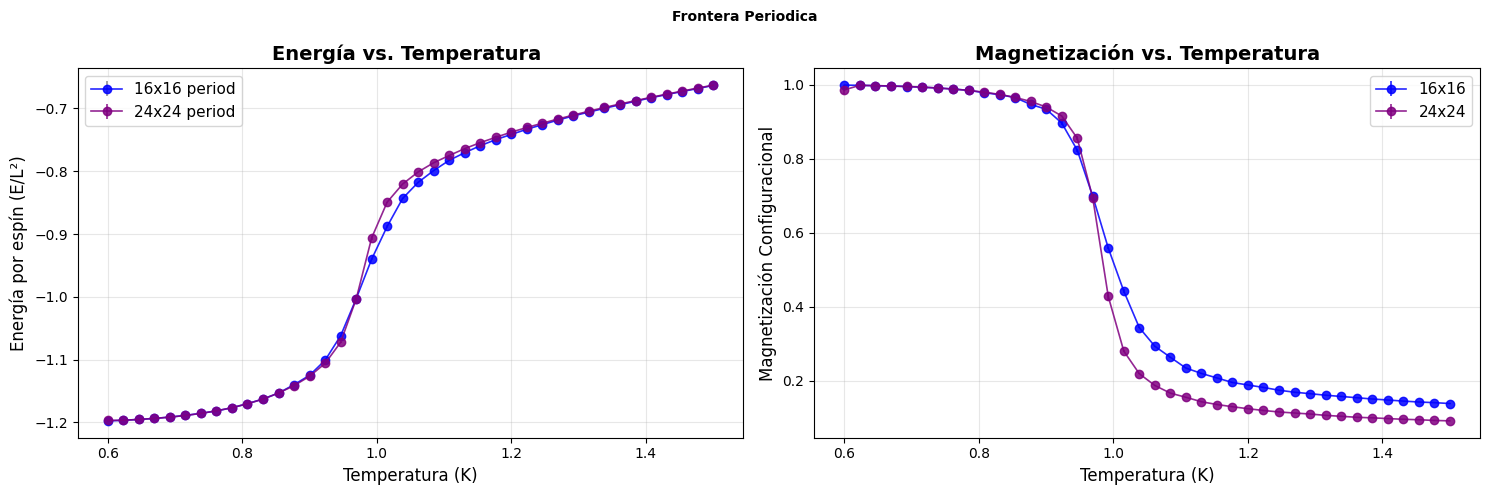

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Frontera Periodica', fontsize=10, fontweight='bold')

axs[0].errorbar(T, E16_config.mean(axis=1)/N16, yerr=E16_sem/N16, fmt ="o-" , color='blue', ecolor='gray', linewidth=1.2, alpha=0.85, label='16x16 period')
axs[0].errorbar(T, E24_config.mean(axis=1)/N24, yerr=E24_sem/N24, fmt ="o-", color='purple', linewidth=1.2, alpha=0.85, label='24x24 period')
axs[0].set_title('Energía vs. Temperatura ', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía por espín (E/L²)', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].errorbar(T, M16_config.mean(axis=1), yerr=M16_sem, fmt ="o-" , color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, M24_config.mean(axis=1), yerr=M24_sem, fmt ="o-" ,  color='purple', linewidth=1.2, alpha=0.85, label='24x24')

axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización Configuracional', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

##Intento de Coeficiente beta

In [ ]:
def estimar_beta(T_arr, Ms_arr, T_N, rango_min=0.02, rango_max=0.3):
    """
    Ajusta Ms(T) ~ (T_N - T)^beta usando los puntos con T < T_N,
    dentro de una ventana [rango_min, rango_max] por debajo de T_N.
    """
    T_arr = np.array(T_arr)
    Ms_arr = np.array(Ms_arr)

    delta_T = T_N - T_arr
    mask = (delta_T > rango_min) & (delta_T < rango_max) & (Ms_arr > 0)

    if mask.sum() < 3:
        print("Muy pocos puntos en el rango seleccionado — amplía rango_min/rango_max")
        return None

    x = np.log(delta_T[mask])
    y = np.log(Ms_arr[mask])

    beta, intercepto = np.polyfit(x, y, 1)

    # Gráfica de verificación
    plt.figure(figsize=(7,5))
    plt.scatter(x, y, color='#2563eb', label='Datos (log-log)')
    plt.plot(x, beta*x + intercepto, color='#dc2626', linestyle='--',
              label=f'Ajuste: β ≈ {beta:.3f}')
    plt.xlabel(r'$\ln(T_N - T)$')
    plt.ylabel(r'$\ln(M_s)$')
    plt.title('Estimación exploratoria de β')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"β estimado: {beta:.3f}  (valor teórico Ising 2D: 0.125)")
    print(f"Puntos usados en el ajuste: {mask.sum()}")

    return beta

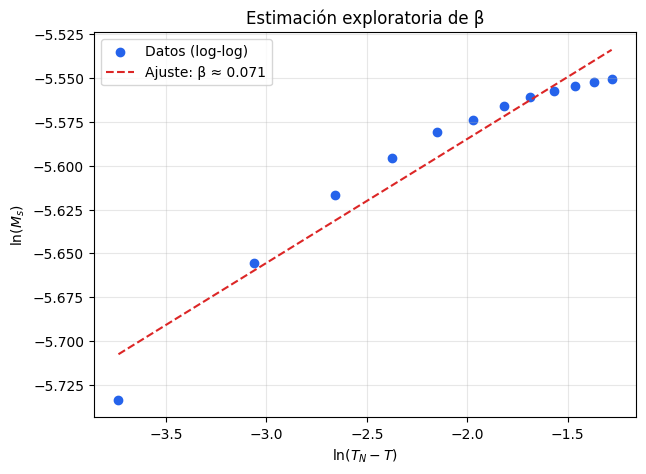

β estimado: 0.071  (valor teórico Ising 2D: 0.125)
Puntos usados en el ajuste: 12


In [ ]:
beta_L16 = estimar_beta(T,M16_config.mean(axis=1)/N16 , T_N=0.97)

##χs, Cv y U
Calcular χs, Cv y U a partir de las muestras


La susceptibilidad de subred y el calor específico no son cantidades promedio, sino medidas de fluctuación estadística, definidas respectivamente como

$$\chi_s = \frac{N}{k_BT}\left(\langle M_s^2\rangle-\langle M_s\rangle^2\right), \qquad C_v = \frac{\langle E^2\rangle-\langle E\rangle^2}{Nk_BT^2}.$$

Su origen físico se explica mediante el teorema de fluctuación-disipación, según el cual la manera en que un sistema responde a un estímulo externo está determinada por la magnitud de sus fluctuaciones espontáneas en equilibrio

In [ ]:
@njit(cache=True, fastmath=True)
def observables(E, Ms, L, T, kB, t_rx):  #E,Ms arrays de una simulacion
    E = E[t_rx:]
    Ms = Ms[t_rx:]   #Ignorar los primeros valores antes del tiempo de termalizacion
    N = L * L

    #Promedios Simples
    E_mean  = E.mean()
    Ms_mean = Ms.mean()

    #Promedios de Potencias
    E2_mean  = (E**2).mean()
    Ms2_mean = (Ms**2).mean()
    Ms4_mean = (Ms**4).mean()

    Cv    = (E2_mean - E_mean**2) / (N * kB * T**2)  #calor especifico
    chi_s = (N / (kB * T)) * (Ms2_mean - Ms_mean**2) #susceptibilidad Magnetica
    U     = 1 - Ms4_mean / (3 * Ms2_mean**2)         #Cumulante de Binder

    return Cv, chi_s, U

Para poder estimar la incertidumbre estadística de χs y Cv, en vez de
calcular estos observables a partir de una única trayectoria de Monte Carlo
por temperatura, se repite la simulación completa **n_rep = 5** veces
(independientes) para cada T. Con esas repeticiones se calcula el promedio y
la desviación estándar muestral (ddof=1) de χs, Cv y U, y esta última se usa
como barra de error en las gráficas.

In [ ]:
@njit(cache=True, fastmath=True, parallel=True)
def barrido_con_error(L, N, T_array, J1, J2, kB, periodic, t_rx, n_rep=5):
    """Para cada T en T_array corre n_rep simulaciones MCS independientes,
    calcula Cv, chi_s y U en cada una, y devuelve el promedio y la
    desviación estándar (ddof=1) de cada observable sobre esas repeticiones."""
    n_T = len(T_array)

    Cv_mean  = np.empty(n_T); Cv_err  = np.empty(n_T)
    chi_mean = np.empty(n_T); chi_err = np.empty(n_T)
    U_mean   = np.empty(n_T); U_err   = np.empty(n_T)

    for t in prange(n_T):
        Cv_reps  = np.empty(n_rep)
        chi_reps = np.empty(n_rep)
        U_reps   = np.empty(n_rep)

        for r in range(n_rep):
            E_r, M_r = MCS(L, N, J1, J2, T_array[t], kB, periodic)
            Cv_r, chi_r, U_r = observables(E_r, M_r, L, T_array[t], kB, t_rx)
            Cv_reps[r]  = Cv_r
            chi_reps[r] = chi_r
            U_reps[r]   = U_r

        Cv_mean[t]  = Cv_reps.mean()
        chi_mean[t] = chi_reps.mean()
        U_mean[t]   = U_reps.mean()

        # Desviación estándar muestral (ddof=1) calculada a mano, para no
        # depender de que la versión de Numba soporte ddof en .std().
        Cv_err[t]  = np.sqrt(((Cv_reps  - Cv_mean[t])**2).sum()  / (n_rep - 1))
        chi_err[t] = np.sqrt(((chi_reps - chi_mean[t])**2).sum() / (n_rep - 1))
        U_err[t]   = np.sqrt(((U_reps   - U_mean[t])**2).sum()   / (n_rep - 1))

    return Cv_mean, Cv_err, chi_mean, chi_err, U_mean, U_err

In [ ]:
#para L = 16          #periodicas (5 repeticiones independientes por T -> promedio + error)
Cv16, Cv16_err, chi_s16, chi_s16_err, U16, U16_err = barrido_con_error(L=16, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=True, t_rx=t_rx_periodico, n_rep=5)

#para L = 24
Cv24, Cv24_err, chi_s24, chi_s24_err, U24, U24_err = barrido_con_error(L=24, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=True, t_rx=t_rx_periodico, n_rep=5)

In [ ]:
#para L = 16          #libres (mismo procedimiento, con más pasos MCS: N_LIBRE)
Cv16_f, Cv16_f_err, chi_s16_f, chi_s16_f_err, U16_f, U16_f_err = barrido_con_error(L=16, N=N_LIBRE, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=False, t_rx=t_rx_libre, n_rep=5)

#para L = 24
Cv24_f, Cv24_f_err, chi_s24_f, chi_s24_f_err, U24_f, U24_f_err = barrido_con_error(L=24, N=N_LIBRE, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=False, t_rx=t_rx_libre, n_rep=5)

#Parte B: Analisis de Resultados

##Transiciones de fase y condiciones de Frontera
Grafique Ms(T) y χs(T) para ambos tamaños de red y ambas condiciones de
frontera.


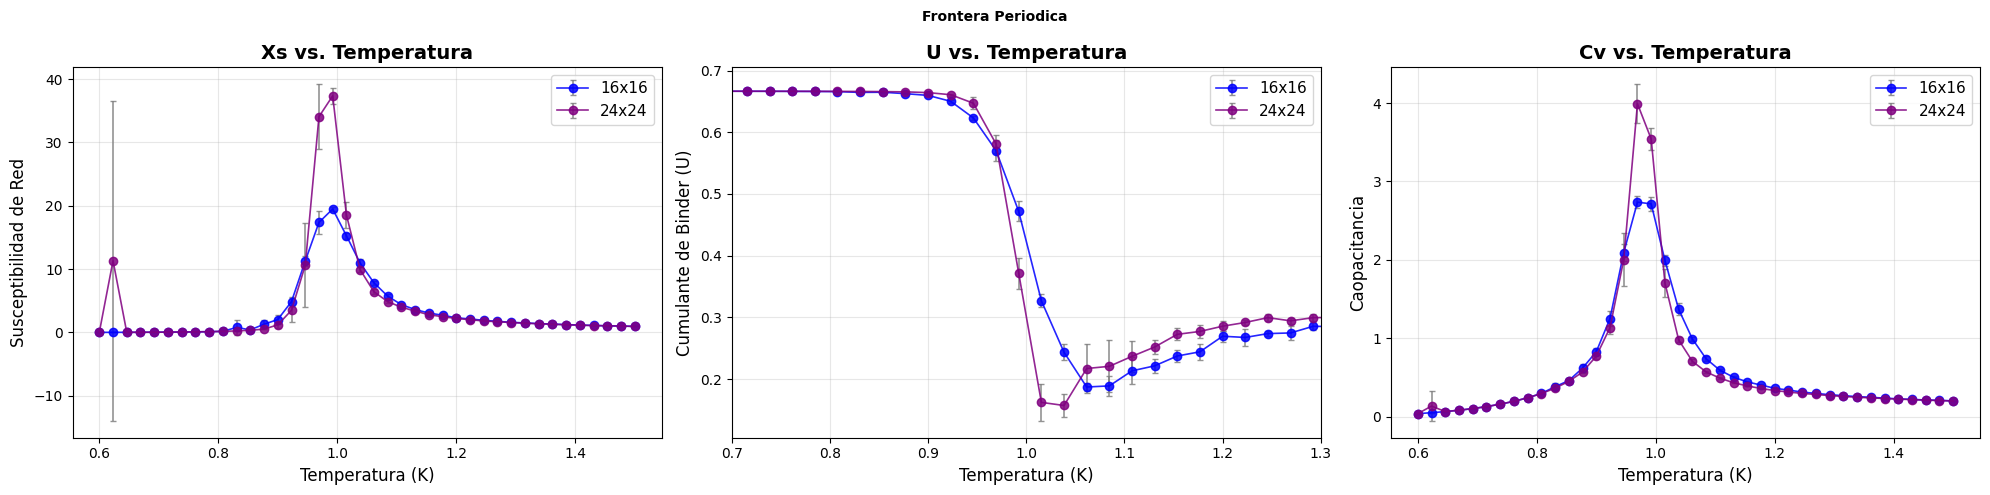

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Frontera Periodica', fontsize=10, fontweight='bold')


axs[0].errorbar(T, chi_s16, yerr=chi_s16_err, fmt="o-", color='blue', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[0].errorbar(T, chi_s24, yerr=chi_s24_err, fmt="o-", color='purple', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Xs vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Susceptibilidad de Red', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].errorbar(T, U16, yerr=U16_err, fmt="o-", color='blue', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, U24, yerr=U24_err, fmt="o-", color='purple', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24")
axs[1].set_title('U vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder (U)', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)
axs[1].set_xlim(0.7, 1.3)  # recorte para poder ver bien la intersección de las curvas


axs[2].errorbar(T, Cv16, yerr=Cv16_err, fmt="o-", color='blue', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[2].errorbar(T, Cv24, yerr=Cv24_err, fmt="o-", color='purple', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24")
axs[2].set_title('Cv vs. Temperatura', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Temperatura (K)', fontsize=12)
axs[2].set_ylabel('Caopacitancia', fontsize=12)
axs[2].grid(True, alpha=0.3)
axs[2].legend(fontsize=11)
axs[2].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

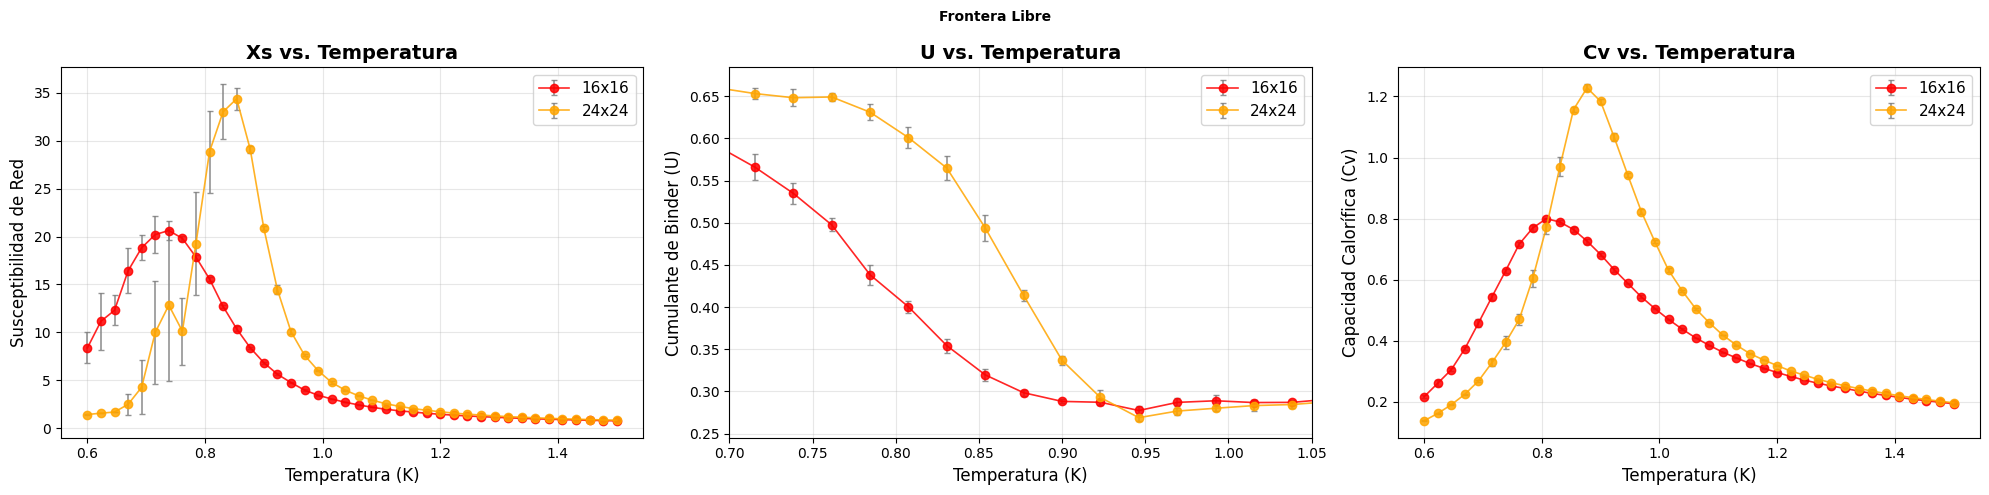

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Frontera Libre', fontsize=10, fontweight='bold')

axs[0].errorbar(T, chi_s16_f, yerr=chi_s16_f_err, fmt="o-", color='red', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[0].errorbar(T, chi_s24_f, yerr=chi_s24_f_err, fmt="o-", color='orange', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Xs vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Susceptibilidad de Red', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].errorbar(T, U16_f, yerr=U16_f_err, fmt="o-", color='red', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, U24_f, yerr=U24_f_err, fmt="o-", color='orange', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24")

axs[1].set_title('U vs. Temperatura',  fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder (U)', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)
axs[1].set_xlim(0.7, 1.05)  # recorte para poder ver bien la intersección de las curvas


axs[2].errorbar(T, Cv16_f, yerr=Cv16_f_err, fmt="o-", color='red', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[2].errorbar(T, Cv24_f, yerr=Cv24_f_err, fmt="o-", color='orange', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24")

axs[2].set_title('Cv vs. Temperatura', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Temperatura (K)', fontsize=12)
axs[2].set_ylabel('Capacidad Calorífica (Cv)', fontsize=12)
axs[2].grid(True, alpha=0.3)
axs[2].legend(fontsize=11)
axs[2].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

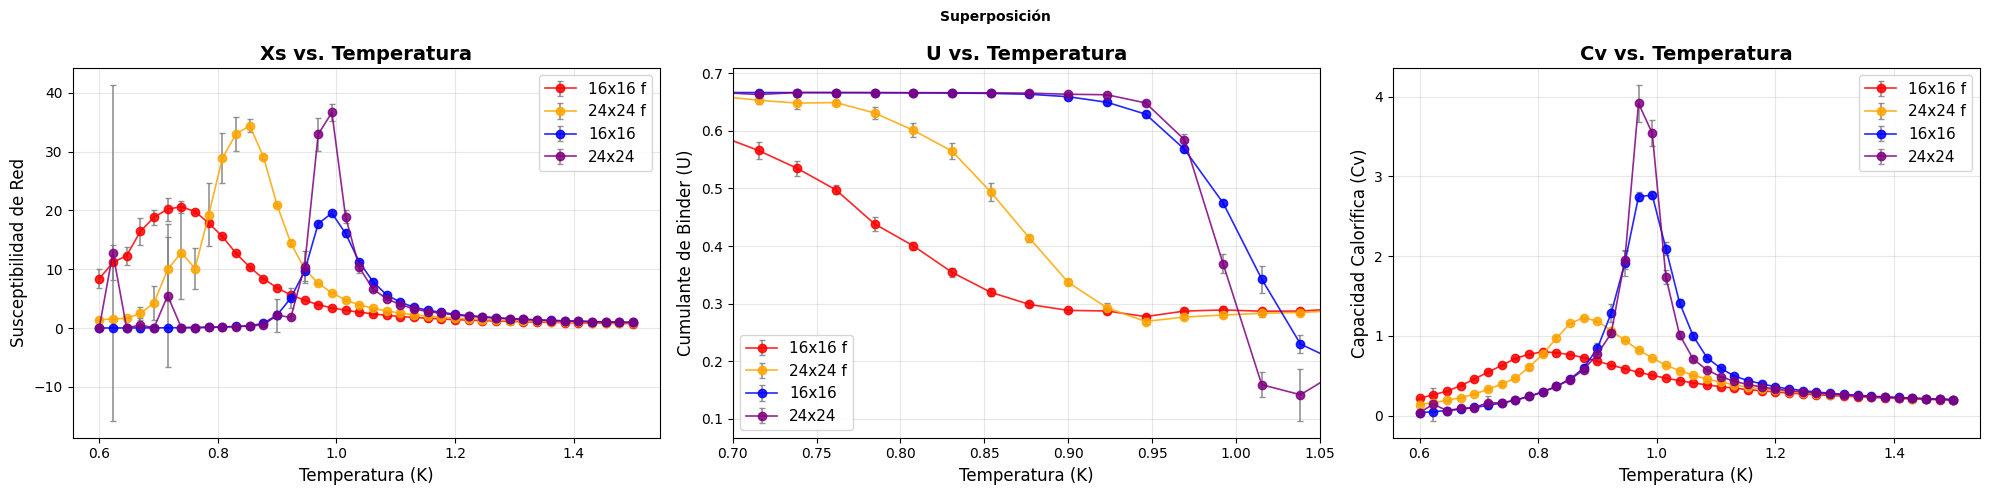

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Superposición', fontsize=10, fontweight='bold')

axs[0].errorbar(T, chi_s16_f, yerr=chi_s16_f_err, fmt="o-", color='red', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16 f')
axs[0].errorbar(T, chi_s24_f, yerr=chi_s24_f_err, fmt="o-", color='orange', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='24x24 f')
axs[0].errorbar(T, chi_s16, yerr=chi_s16_err, fmt="o-", color='blue', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[0].errorbar(T, chi_s24, yerr=chi_s24_err, fmt="o-", color='purple', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Xs vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Susceptibilidad de Red', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].errorbar(T, U16_f, yerr=U16_f_err, fmt="o-", color='red', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16 f')
axs[1].errorbar(T, U24_f, yerr=U24_f_err, fmt="o-", color='orange', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24 f")

axs[1].errorbar(T, U16, yerr=U16_err, fmt="o-", color='blue', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, U24, yerr=U24_err, fmt="o-", color='purple', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24")

axs[1].set_title('U vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder (U)', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)
axs[1].set_xlim(0.7, 1.05)  # recorte para poder ver bien la intersección de las curvas

axs[2].errorbar(T, Cv16_f, yerr=Cv16_f_err, fmt="o-", color='red', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16 f')
axs[2].errorbar(T, Cv24_f, yerr=Cv24_f_err, fmt="o-", color='orange', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24 f")
axs[2].errorbar(T, Cv16, yerr=Cv16_err, fmt="o-", color='blue', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label='16x16')
axs[2].errorbar(T, Cv24, yerr=Cv24_err, fmt="o-", color='purple', ecolor='gray', capsize=2, linewidth=1.2, alpha=0.85, label="24x24")
axs[2].set_title('Cv vs. Temperatura', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Temperatura (K)', fontsize=12)
axs[2].set_ylabel('Capacidad Calorífica (Cv)', fontsize=12)
axs[2].grid(True, alpha=0.3)
axs[2].legend(fontsize=11)
axs[2].tick_params(labelsize=10)


plt.tight_layout()
plt.show()


###  Efecto de las condiciones de frontera sobre $M_s(T)$ y $\chi_s

---

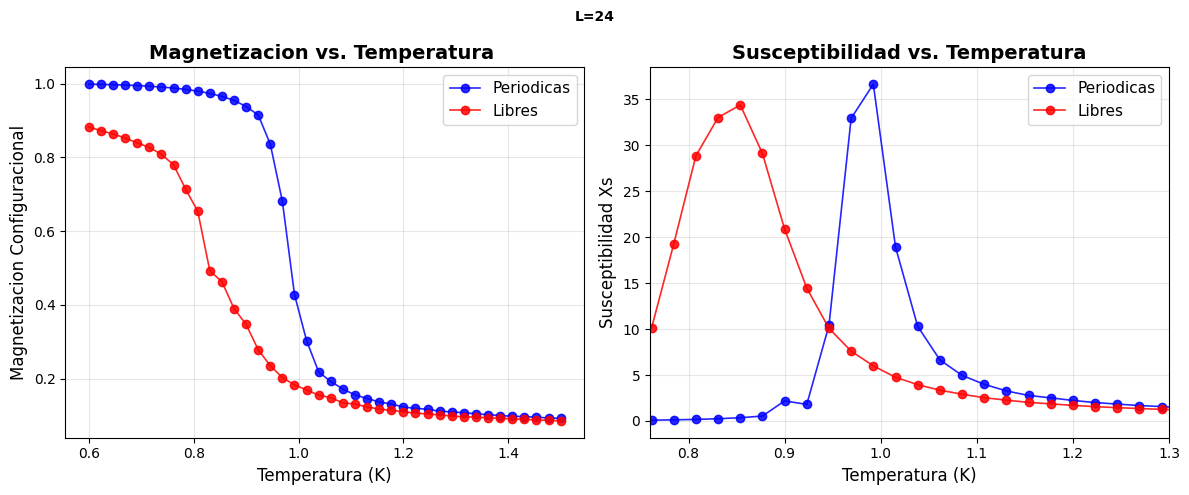

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('L=24', fontsize=10, fontweight='bold')

axs[0].plot(T, M24_config.mean(axis=1), "-o", color='blue', linewidth=1.2, alpha=0.85, label='Periodicas')
axs[0].plot(T, M24_config_free.mean(axis=1),"-o" ,color='red', linewidth=1.2, alpha=0.85, label='Libres')
axs[0].set_title('Magnetizacion vs. Temperatura ', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Magnetizacion Configuracional', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, chi_s24, "-o", color='blue', linewidth=1.2, alpha=0.85, label='Periodicas')
axs[1].plot(T, chi_s24_f,"-o", color='red', linewidth=1.2, alpha=0.85, label='Libres')
axs[1].set_title('Susceptibilidad vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Susceptibilidad Xs', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)
axs[1].set_xlim(0.76, 1.3)

plt.tight_layout()
plt.show()


Usando el Cumulante de Binder U(T), determine la temperatura de
Neel TN para cada condicion de frontera. ¿Que metodo (T del pico de χs o cruce de
U) da una estimacion mas estable? Justifique su respuesta.


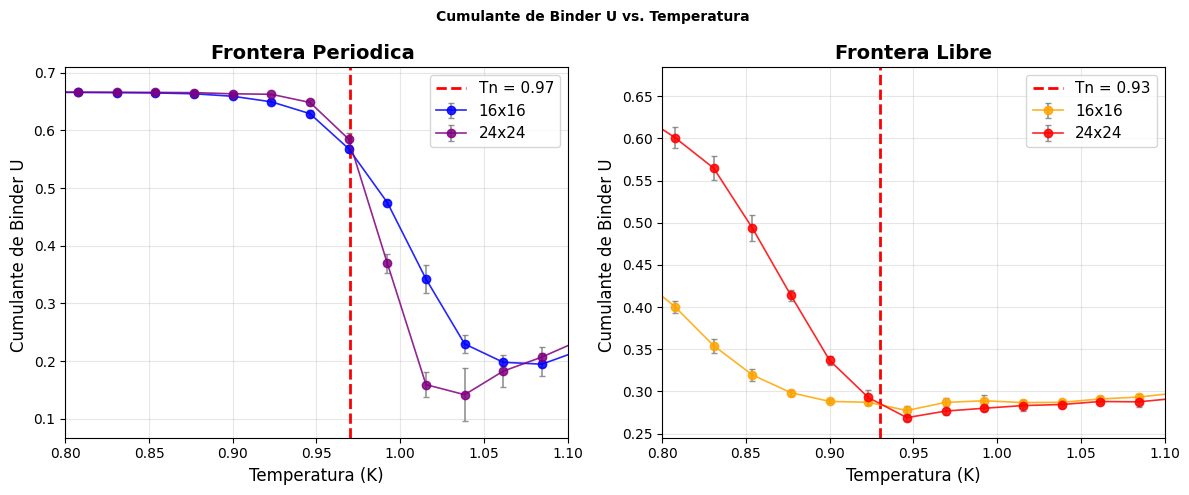

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cumulante de Binder U vs. Temperatura ', fontsize=10, fontweight='bold')

axs[0].errorbar(T, U16, yerr=U16_err, fmt="o-", ecolor='gray', capsize=2, color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].errorbar(T, U24, yerr=U24_err, fmt="o-", ecolor='gray', capsize=2, color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Frontera Periodica ', fontsize=14, fontweight='bold')
axs[0].axvline(x=0.97, color='red', linestyle='--', linewidth=2, label='Tn = 0.97')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Cumulante de Binder U ', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)
axs[0].set_xlim(0.8, 1.1)  # recorte para ver la intersección de las curvas

axs[1].errorbar(T, U16_f, yerr=U16_f_err, fmt="o-", ecolor='gray', capsize=2, color='orange', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, U24_f, yerr=U24_f_err, fmt="o-", ecolor='gray', capsize=2, color='red', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].axvline(x=0.93, color='red', linestyle='--', linewidth=2, label='Tn = 0.93')
axs[1].set_title('Frontera Libre', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder U ', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)
axs[1].set_xlim(0.8, 1.1)  # recorte para ver la intersección de las curvas

plt.tight_layout()
plt.show()

##Efecto Magnetocalorico
Para el sistema con condiciones de frontera peri´odicas y L = 24:



In [3]:
@njit(cache=True, fastmath=True)
def magnetizacion_total(grid):      #MAGNETIZACION UNIFORME
    # Magnetización total del sistema, NO de subred
    N = grid.shape[0]
    suma = 0.0
    for i in range(N):
        for j in range(N):
            suma += grid[i, j]
    return abs(suma) / (N * N)


@njit(cache=True, fastmath=True)
def MCS_h(L, N, J1, J2, T, kB, periodic, h):  #MSC con h
    grid = np.empty((L, L), dtype=np.int8)
    for i in range(L):
        for j in range(L):
            grid[i, j] = 1 if np.random.random() < 0.5 else -1

    E = np.empty(N)
    M = np.empty(N)

    for y in range(N):
        for k in range(L * L):
            a = np.random.randint(0, L)
            b = np.random.randint(0, L)

            E_int = energia_local(grid, a, b, L, J1, J2, periodic)
            # delta_E sin campo: -2*E_int
            # término de campo: al voltear s -> -s, -h*s pasa a +h*s => contribución 2*h*s
            delta_E = -2.0 * E_int + 2.0 * h * grid[a, b]

            if delta_E < 0 or np.random.random() < np.exp(-delta_E / (kB * T)):
                grid[a, b] *= -1

        # energía total incluyendo término Zeeman (sin doble conteo, es a un solo cuerpo)
        campo_total = 0.0
        for i in range(L):
            for j in range(L):
                campo_total += grid[i, j]

        E[y] = Energy_total(grid, periodic) - h * campo_total
        M[y] = magnetizacion_total(grid)

    return E, M

In [4]:
@njit(cache=True, fastmath=True)
def GranMean_h(L, N, Temp, h, n_configs=10, t_rx=20000):
    J1, J2 = 1.0, -0.6
    kB = 1.0

    E_config = np.empty(n_configs)
    M_config = np.empty(n_configs)

    for c in range(n_configs):
        E_, M_ = MCS_h(L, N, J1, J2, Temp, kB, True, h)  # periodic=True fijo, según el enunciado
        E_config[c] = E_[t_rx:].mean()
        M_config[c] = M_[t_rx:].mean()

    return E_config, M_config


@njit(cache=True, fastmath=True, parallel=True)
def barrido_GranMean_h(L, N, T_array, h, n_configs=10, t_rx=20000):
    n_T = len(T_array)
    E_config_all = np.empty((n_T, n_configs))
    M_config_all = np.empty((n_T, n_configs))

    for t in prange(n_T):
        E_c, M_c = GranMean_h(L, N, T_array[t], h, n_configs, t_rx)
        E_config_all[t, :] = E_c
        M_config_all[t, :] = M_c

    return E_config_all, M_config_all

Realice simulaciones con y sin campo magnetico externo (h). Por simplicidad,
calcule ∆SM usando el metodo de integracion numerica de la relacion de
Maxwell. Grafique ∆SM(T) para las dos condiciones de campo.

In [ ]:
t_rx = 20000  #42min

# Sin campo
E_h0_all, M_h0_all = barrido_GranMean_h(24, 100000, T, h=0.0, t_rx=t_rx)
M_h0 = M_h0_all.mean(axis=1)   # promedio sobre las 30 configs, shape (15,)

# Con campo
E_h1_all, M_h1_all = barrido_GranMean_h(24, 100000, T, h=0.5, t_rx=t_rx)
M_h1 = M_h1_all.mean(axis=1)

In [ ]:
def delta_SM(T, M):
    """
    Aplica ec. (7): ΔS_M(T) ≈ [M(T+ΔT) - M(T-ΔT)] / (2ΔT)
    (relación de Maxwell, integrada numéricamente con diferencias finitas).

    Es robusta frente al orden de T: no importa si T viene de mayor a menor
    (como en este notebook, T = np.linspace(1.5, 0.6, 30)) o de menor a
    mayor. Internamente se ordena de forma ascendente para tomar la
    derivada correctamente y el resultado se devuelve en el mismo orden
    que el T de entrada.
    """
    T = np.asarray(T, dtype=float)
    M = np.asarray(M, dtype=float)

    orden = np.argsort(T)          # índices que dejan a T en orden ascendente
    T_asc = T[orden]
    M_asc = M[orden]

    dS_asc = np.gradient(M_asc, T_asc)  # centrada adentro, forward/backward en los bordes

    dS = np.empty_like(dS_asc)
    dS[orden] = dS_asc              # se regresa al orden original de T
    return dS

In [ ]:
dS_h0 = delta_SM(T, M_h0)
dS_h1 = delta_SM(T, M_h1)

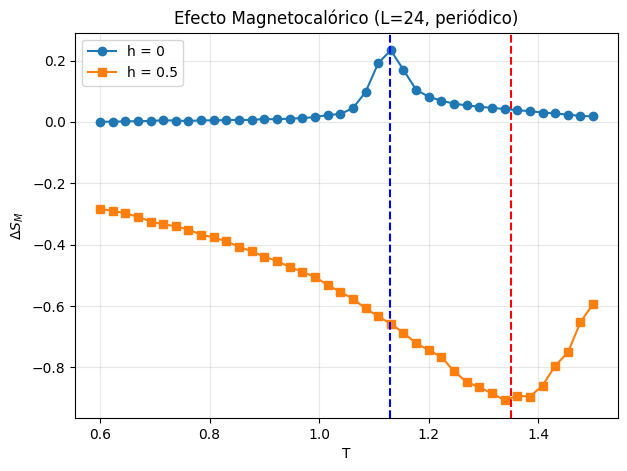

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(T, dS_h0, 'o-', label='h = 0')
plt.plot(T, dS_h1, 's-', label='h = 0.5')
plt.axvline(x=1.13, color='blue', linestyle='--')
plt.axvline(x=1.35, color='red', linestyle='--')
plt.xlabel('T')
plt.ylabel(r'$\Delta S_M$')
plt.title('Efecto Magnetocalórico (L=24, periódico)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Calcule el RCP para el campo h = 0,5 usando el FWHM del pico de
|∆SM|.

In [ ]:
def calcular_RCP(T, dS):
    """
    Calcula el RCP (Relative Cooling Power) a partir del FWHM del pico de
    |ΔS_M|:
        RCP = |ΔS_M|_max * FWHM

    Es robusta frente al orden de T (ordena internamente de forma
    ascendente). Si el pico está muy cerca del borde del rango de T
    simulado y no se encuentra el cruce de la mitad del máximo de un lado,
    se usa el extremo del rango como aproximación (avisando con un mensaje)
    en vez de devolver None en silencio.
    """
    T = np.asarray(T, dtype=float)
    dS_abs = np.abs(np.asarray(dS, dtype=float))

    orden = np.argsort(T)
    T = T[orden]
    dS_abs = dS_abs[orden]

    peak_idx = np.argmax(dS_abs)
    peak_val = dS_abs[peak_idx]
    half_max = peak_val / 2.0

    # Búsqueda del cruce por la izquierda del pico
    izq = None
    for i in range(peak_idx, 0, -1):
        if dS_abs[i-1] <= half_max <= dS_abs[i]:
            # interpolación lineal entre T[i-1] y T[i]
            izq = T[i-1] + (half_max - dS_abs[i-1]) * (T[i]-T[i-1]) / (dS_abs[i]-dS_abs[i-1])
            break
    if izq is None:
        izq = T[0]
        print(f"Aviso: el cruce izquierdo del FWHM cae fuera del rango de T simulado; "
              f"se usa T_min = {T[0]:.3f} como aproximación (el RCP quedará subestimado).")

    # Búsqueda del cruce por la derecha del pico
    der = None
    for i in range(peak_idx, len(T)-1):
        if dS_abs[i+1] <= half_max <= dS_abs[i]:
            der = T[i] + (half_max - dS_abs[i]) * (T[i+1]-T[i]) / (dS_abs[i+1]-dS_abs[i])
            break
    if der is None:
        der = T[-1]
        print(f"Aviso: el cruce derecho del FWHM cae fuera del rango de T simulado; "
              f"se usa T_max = {T[-1]:.3f} como aproximación (el RCP quedará subestimado).")

    fwhm = der - izq
    rcp = peak_val * fwhm
    return rcp, fwhm, peak_val

In [ ]:
rcp, fwhm, peak = calcular_RCP(T, dS_h1)
print(f"Pico |ΔS_M| (h = 0.5) = {peak:.4f}")
print(f"FWHM                  = {fwhm:.4f}")
print(f"RCP                   = {rcp:.4f}")


Pico |ΔS_M| (h = 0.5) = 0.9053

FWHM                  = 0.5834

RCP                   = 0.5281